<a href="https://colab.research.google.com/github/chanita-lab/GE338-Code/blob/main/LAB_3/Lab3_comparison_6606614680_%E0%B8%8A%E0%B8%99%E0%B8%B4%E0%B8%95%E0%B8%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install & Import Libraries

!pip install geopandas rasterio folium geemap earthengine-api shapely pyproj fiona rtree scikit-learn -q

import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import numpy as np
import ee
import geemap

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, cohen_kappa_score
from sklearn.model_selection import train_test_split

In [ ]:
ee.Authenticate()
ee.Initialize(project='ee-chanita')

# ROI
roi = ee.Geometry.Polygon([
    [[100.145,15.695],
     [100.375,15.695],
     [100.375,15.560],
     [100.145,15.560],
     [100.145,15.695]]
])

# Sentinel-2 composite
image = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
         .filterBounds(roi)
         .filterDate('2024-01-01','2024-12-31')
         .median()
         .clip(roi))

# Indices
ndvi = image.normalizedDifference(['B8','B4']).rename('NDVI')
ndwi = image.normalizedDifference(['B3','B8']).rename('NDWI')
ndbi = image.normalizedDifference(['B11','B8']).rename('NDBI')

# Features
features = image.select(['B2','B3','B4','B8']).addBands([ndvi,ndwi,ndbi])

# Dynamic World labels
dw = (ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
      .filterBounds(roi)
      .filterDate('2024-01-01','2024-12-31')
      .select('label')
      .median()
      .clip(roi))

remapped = dw.remap(
    [0,3,4,1,6,2,5,7,8],
    [1,2,3,4,5,2,2,2,2]
).rename('class')

# Sampling
samples = features.addBands(remapped).sample(
    region=roi,
    scale=10,
    numPixels=6000,
    seed=10,
    geometries=True
).filter(ee.Filter.notNull(['class']))

# Train / Test split
samples = samples.randomColumn('random')

train = samples.filter(ee.Filter.lt('random',0.8))
test = samples.filter(ee.Filter.gte('random',0.8))

In [ ]:
# Random Forest (50 trees)
rf50 = ee.Classifier.smileRandomForest(
    numberOfTrees=50
).train(
    features=train,
    classProperty='class',
    inputProperties=features.bandNames()
)

rf_test = test.classify(rf50)

rf_matrix = rf_test.errorMatrix('class','classification')

print('RF Confusion Matrix:', rf_matrix.getInfo())
print('RF Overall Accuracy:', rf_matrix.accuracy().getInfo())
print('RF Kappa:', rf_matrix.kappa().getInfo())

producers = [i[0] for i in rf_matrix.producersAccuracy().getInfo()]
users = rf_matrix.consumersAccuracy().getInfo()[0]

print("Producer's Accuracy:", producers)
print("User's Accuracy:", users)

f1_scores = []

for p,u in zip(producers,users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    f1_scores.append(f1)

print("F1-score per class:",f1_scores)

RF Confusion Matrix: [[0, 0, 0, 0, 0, 0], [0, 47, 20, 9, 0, 1], [0, 15, 78, 100, 16, 6], [0, 10, 22, 624, 3, 9], [0, 8, 16, 28, 20, 1], [0, 0, 4, 71, 4, 28]]
RF Overall Accuracy: 0.6991228070175438
RF Kappa: 0.44108860650934084
Producer's Accuracy: [0, 0.6103896103896104, 0.3627906976744186, 0.9341317365269461, 0.273972602739726, 0.2616822429906542]
User's Accuracy: [0, 0.5875, 0.5571428571428572, 0.75, 0.46511627906976744, 0.6222222222222222]
F1-score per class: [0, 0.5987261146496815, 0.4394366197183099, 0.8320000000000001, 0.3448275862068965, 0.3684210526315789]


Random Forest Accuracy: 0.6991
Random Forest Kappa: 0.4411


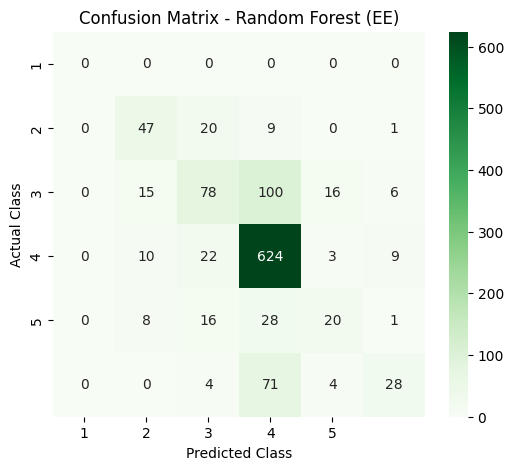

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix Random Forest
rf50_acc = rf_matrix.accuracy().getInfo()
rf50_kappa = rf_matrix.kappa().getInfo()
rf50_matrix = rf_matrix # Use rf_matrix from previous execution

print(f"Random Forest Accuracy: {rf50_acc:.4f}")
print(f"Random Forest Kappa: {rf50_kappa:.4f}")

cm_rf = np.array(rf50_matrix.getInfo())

class_names = [1,2,3,4,5]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Random Forest (EE)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

In [ ]:
# Random Forest (100 trees)
rf100 = ee.Classifier.smileRandomForest(
    numberOfTrees=100
).train(
    features=train,
    classProperty='class',
    inputProperties=features.bandNames()
)

rf_test = test.classify(rf100)

rf_matrix = rf_test.errorMatrix('class','classification')

print('RF Confusion Matrix:', rf_matrix.getInfo())
print('RF Overall Accuracy:', rf_matrix.accuracy().getInfo())
print('RF Kappa:', rf_matrix.kappa().getInfo())

producers = [i[0] for i in rf_matrix.producersAccuracy().getInfo()]
users = rf_matrix.consumersAccuracy().getInfo()[0]

print("Producer's Accuracy:", producers)
print("User's Accuracy:", users)

f1_scores = []

for p,u in zip(producers,users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    f1_scores.append(f1)

print("F1-score per class:",f1_scores)

RF Confusion Matrix: [[0, 0, 0, 0, 0, 0], [0, 40, 23, 13, 0, 1], [0, 14, 81, 102, 13, 5], [0, 9, 19, 628, 5, 7], [0, 6, 16, 29, 21, 1], [0, 0, 4, 70, 5, 28]]
RF Overall Accuracy: 0.7
RF Kappa: 0.4377109233032391
Producer's Accuracy: [0, 0.5194805194805194, 0.3767441860465116, 0.9401197604790419, 0.2876712328767123, 0.2616822429906542]
User's Accuracy: [0, 0.5797101449275363, 0.5664335664335665, 0.7458432304038005, 0.4772727272727273, 0.6666666666666666]
F1-score per class: [0, 0.5479452054794519, 0.45251396648044695, 0.8317880794701986, 0.3589743589743589, 0.3758389261744966]


In [ ]:
# Gradient Tree Boost
gtb = ee.Classifier.smileGradientTreeBoost(
    numberOfTrees=100,
    shrinkage=0.1,
    maxNodes=20
).train(
    features=train,
    classProperty='class',
    inputProperties=features.bandNames()
)

gtb_test = test.classify(gtb)

gtb_matrix = gtb_test.errorMatrix('class','classification')

print('GTB Confusion Matrix:',gtb_matrix.getInfo())
print('GTB Overall Accuracy:',gtb_matrix.accuracy().getInfo())
print('GTB Kappa:',gtb_matrix.kappa().getInfo())

producers = [i[0] for i in gtb_matrix.producersAccuracy().getInfo()]
users = gtb_matrix.consumersAccuracy().getInfo()[0]

print("Producer's Accuracy:", producers)
print("User's Accuracy:", users)

f1_scores=[]

for p,u in zip(producers,users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    f1_scores.append(f1)

print("F1-score per class:",f1_scores)


GTB Confusion Matrix: [[0, 0, 0, 0, 0, 0], [0, 43, 23, 10, 0, 1], [0, 17, 78, 105, 9, 6], [0, 11, 24, 619, 6, 8], [0, 5, 20, 29, 19, 0], [0, 0, 4, 71, 4, 28]]
GTB Overall Accuracy: 0.6903508771929825
GTB Kappa: 0.4228270316941709
Producer's Accuracy: [0, 0.5584415584415584, 0.3627906976744186, 0.9266467065868264, 0.2602739726027397, 0.2616822429906542]
User's Accuracy: [0, 0.5657894736842105, 0.5234899328859061, 0.7422062350119905, 0.5, 0.6511627906976745]
F1-score per class: [0, 0.5620915032679739, 0.4285714285714286, 0.8242343541944074, 0.34234234234234234, 0.3733333333333333]


In [ ]:
# Confusion Matrix Gradient Tree Boost
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_gtb = np.array(gtb_matrix.getInfo())

gtb_test = test.classify(gtb)

gtb_matrix = gtb_test.errorMatrix('class','classification')

print("GTB Confusion Matrix:")
print(gtb_matrix.getInfo())

GTB Confusion Matrix:
[[0, 0, 0, 0, 0, 0], [0, 43, 23, 10, 0, 1], [0, 17, 78, 105, 9, 6], [0, 11, 24, 619, 6, 8], [0, 5, 20, 29, 19, 0], [0, 0, 4, 71, 4, 28]]


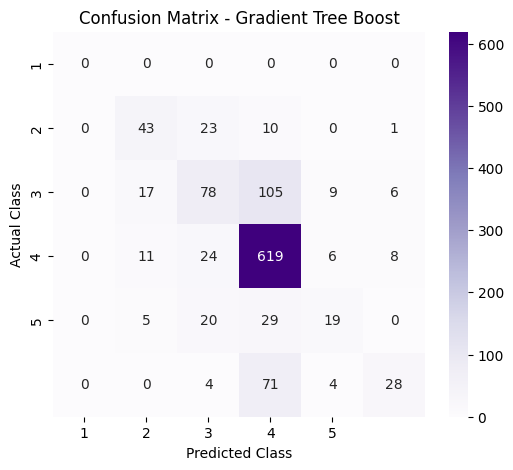

In [ ]:
class_names = [1,2,3,4,5]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_gtb,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Gradient Tree Boost")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()

**เปรียบเทียบ Model Random Forest & Gradient Tree Boost**

In [ ]:
# Random Forest (50 trees)

rf50 = ee.Classifier.smileRandomForest(
    numberOfTrees=50
).train(
    features=train,
    classProperty='class',
    inputProperties=features.bandNames()
)

rf50_test = test.classify(rf50)
rf50_matrix = rf50_test.errorMatrix('class','classification')

rf50_acc = rf50_matrix.accuracy().getInfo()
rf50_kappa = rf50_matrix.kappa().getInfo()

rf50_producers = [i[0] for i in rf50_matrix.producersAccuracy().getInfo()]
rf50_users = rf50_matrix.consumersAccuracy().getInfo()[0]

rf50_f1 = []
for p,u in zip(rf50_producers,rf50_users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    rf50_f1.append(f1)

# Gradient Tree Boost

gtb_test = test.classify(gtb)
gtb_matrix = gtb_test.errorMatrix('class','classification')

gtb_acc = gtb_matrix.accuracy().getInfo()
gtb_kappa = gtb_matrix.kappa().getInfo()

gtb_producers = [i[0] for i in gtb_matrix.producersAccuracy().getInfo()]
gtb_users = gtb_matrix.consumersAccuracy().getInfo()[0]

gtb_f1 = []
for p,u in zip(gtb_producers,gtb_users):
    if (p+u)==0:
        f1=0
    else:
        f1=2*(p*u)/(p+u)
    gtb_f1.append(f1)

# Comparison

print("===== Model Comparison =====")

print("\nRandom Forest (50 Trees)")
print("Overall Accuracy:", rf50_acc)
print("Kappa:", rf50_kappa)
print("Producer's Accuracy:", rf50_producers)
print("User's Accuracy:", rf50_users)
print("F1-score:", rf50_f1)

print("\nGradient Tree Boost")
print("Overall Accuracy:", gtb_acc)
print("Kappa:", gtb_kappa)
print("Producer's Accuracy:", gtb_producers)
print("User's Accuracy:", gtb_users)
print("F1-score:", gtb_f1)

===== Model Comparison =====

Random Forest (50 Trees)
Overall Accuracy: 0.6991228070175438
Kappa: 0.44108860650934084
Producer's Accuracy: [0, 0.6103896103896104, 0.3627906976744186, 0.9341317365269461, 0.273972602739726, 0.2616822429906542]
User's Accuracy: [0, 0.5875, 0.5571428571428572, 0.75, 0.46511627906976744, 0.6222222222222222]
F1-score: [0, 0.5987261146496815, 0.4394366197183099, 0.8320000000000001, 0.3448275862068965, 0.3684210526315789]

Gradient Tree Boost
Overall Accuracy: 0.6903508771929825
Kappa: 0.4228270316941709
Producer's Accuracy: [0, 0.5584415584415584, 0.3627906976744186, 0.9266467065868264, 0.2602739726027397, 0.2616822429906542]
User's Accuracy: [0, 0.5657894736842105, 0.5234899328859061, 0.7422062350119905, 0.5, 0.6511627906976745]
F1-score: [0, 0.5620915032679739, 0.4285714285714286, 0.8242343541944074, 0.34234234234234234, 0.3733333333333333]


In [ ]:
# Classification images
rf_classified = features.classify(rf50)
gtb_classified = features.classify(gtb)

# Map
Map_gtb = geemap.Map()
Map_gtb.centerObject(roi, 11)

# Random Forest layer
Map_gtb.addLayer(
    rf_classified,
    {'min':1,'max':5,'palette':['blue','cyan','yellow','green','red']},
    'Random Forest Classification'
)

# Gradient Tree Boost layer
Map_gtb.addLayer(
    gtb_classified,
    {'min':1,'max':5,'palette':['blue','cyan','yellow','green','red']},
    'Gradient Tree Boost Classification'
)

# Legend
legend_keys = ['Water','Wetland Vegetation','Agriculture','Forest','Urban']
legend_colors = [
    (0, 0, 255),    # Blue
    (0, 255, 255),  # Cyan
    (255, 255, 0),  # Yellow
    (0, 128, 0),    # Green
    (255, 0, 0)     # Red
]

Map_gtb.add_legend(
    title='Land Cover Classes',
    keys=legend_keys,
    colors=legend_colors
)

Map_gtb

Map(center=[15.627522525394701, 100.26000000000056], controls=(WidgetControl(options=['position', 'transparent…

**วิเคราะห์ Feature Importance**

Feature Importance Values
NDBI = 1186.08
B2 = 1158.15
B3 = 1128.94
B8 = 1119.98
NDWI = 1104.02
B4 = 1095.37
NDVI = 1086.88


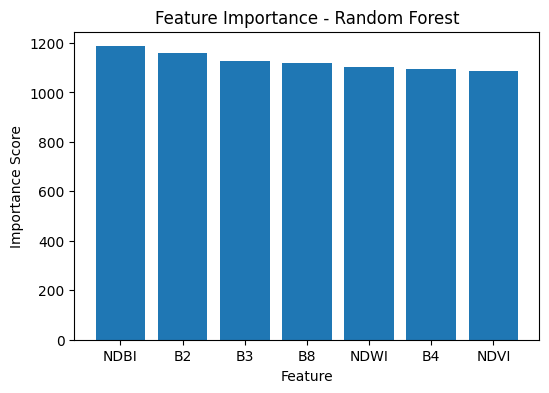

In [ ]:
# Feature Importance (Random Forest)
import pandas as pd

# B2 B4 B3 B8 NDWI NDVI NDBI
importance = rf50.explain().get('importance').getInfo()

# แปลงเป็น DataFrame
df_importance = pd.DataFrame({
    "Feature": list(importance.keys()),
    "Importance": list(importance.values())
})

# เรียงค่าจากมากไปน้อย
df_importance = df_importance.sort_values(by="Importance", ascending=False)

print("Feature Importance Values")
for i, row in df_importance.iterrows():
    print(f"{row['Feature']} = {row['Importance']:.2f}")

plt.figure(figsize=(6,4))

plt.bar(df_importance["Feature"], df_importance["Importance"])

plt.title("Feature Importance - Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance Score")

# Export รูป
plt.savefig("FeatureImportance_RF.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
# Features without NDVI
features_no_ndvi = features.select(['B2','B3','B4','B8','NDWI','NDBI'])

# Train Random Forest
rf_no_ndvi = ee.Classifier.smileRandomForest(50).train(
    features=train,
    classProperty='class',
    inputProperties=features_no_ndvi.bandNames()
)

# Evaluate
rf_test_no_ndvi = test.classify(rf_no_ndvi)
rf_matrix_no_ndvi = rf_test_no_ndvi.errorMatrix('class','classification')

print("Accuracy without NDVI:", rf_matrix_no_ndvi.accuracy().getInfo())
print("Kappa without NDVI:", rf_matrix_no_ndvi.kappa().getInfo())

Accuracy without NDVI: 0.6956140350877194
Kappa without NDVI: 0.43413634913664245
